<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  20 non-null     object 
 1   date       20 non-null     object 
 2   product    20 non-null     object 
 3   batch      20 non-null     object 
 4   parameter  20 non-null     object 
 5   value      20 non-null     float64
 6   unit       13 non-null     object 
 7   method     20 non-null     object 
 8   operator   20 non-null     object 
 9   status     20 non-null     object 
dtypes: float64(1), object(9)
memory usage: 1.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   sample_id  20 non-null     object        
 1   date       20 non-null     datetime64[ns]
 2   product    20 non-null     object        
 3   batch      20 non-null

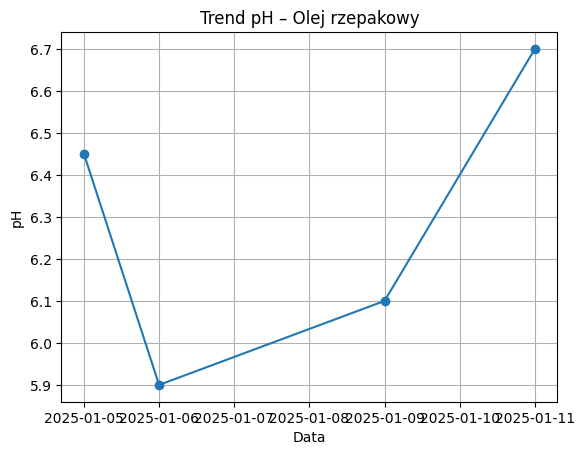

,status,count
0,OK,14
1,OOS,6


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from app.qc import merge_with_spec, add_in_spec, oos_report

df = pd.read_csv("result.csv")
df.head()
df.info()
df["date"] = pd.to_datetime(df["date"])
df.info()

results_count = (
    df
    .groupby(["product", "parameter"])
    .size()
    .reset_index(name="count")
)


stats = (
    df
    .groupby(["product", "parameter"])["value"]
    .agg(mean_value="mean", std_value="std")
    .reset_index()
)


oil_ph = df[
    (df["product"] == "Olej rzepakowy") &
    (df["parameter"] == "pH")
]

plt.figure()
plt.plot(oil_ph["date"], oil_ph["value"], marker="o")
plt.title("Trend pH – Olej rzepakowy")
plt.xlabel("Data")
plt.ylabel("pH")
plt.grid(True)
plt.show()

status_count = df["status"].value_counts().reset_index()
status_count.columns = ["status", "count"]

status_count

In [ ]:
# ## Conclusions
#
# - The dataset contains laboratory test results for two products: rapeseed oil and moisturizing cream.
# - The most frequently analyzed parameters are pH, density, and viscosity.
# - Variability in the pH values of rapeseed oil over time is observed.
# - Some results are marked as OOS (Out of Specification), indicating potential quality issues in selected batches.
# - The data is suitable for further analysis, such as comparison against specifications/standards or long-term trend analysis.